# Getting started

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/relatipy/blob/main/docs/tutorials/01-getting-started.ipynb)

Three short use cases, each a few lines long and ending in a figure:

- a first orbit around a spinning black hole;
- prograde against retrograde motion;
- a star on an S2-like orbit around Sgr A*.

Later tutorials explain each step in detail.

In [ ]:
%pip install -Uq relatipy

In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import c

import relatipy as rp

## 1. A first orbit

Create a black hole with a mass and a dimensionless spin, then an orbit from
classical elements:

- semi-major axis `a`;
- eccentricity `e`;
- inclination `inc` with respect to the equatorial plane.

Lengths are written as multiples of the
Schwarzschild radius $r_s = 2GM/c^2$, available as `bh.r_s`, and expressed in
kilometres so the figures use readable numbers. Before integrating, `orbit.preview()`
draws the instantaneous Kepler ellipse of the starting point together with the
outer horizon and the prograde and retrograde ISCO, a quick check of the initial
conditions.

r_s = 29.532500761002495 km


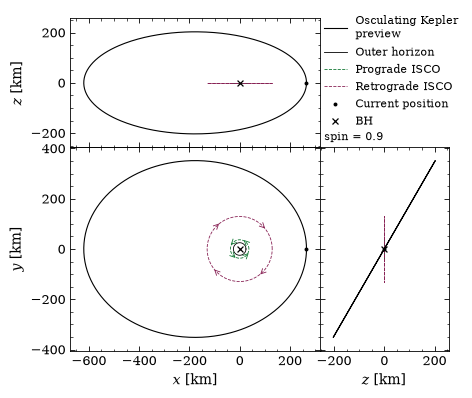

In [2]:
bh = rp.Kerr(mass=10 * u.Msun, spin=0.9)
print("r_s =", bh.r_s.to(u.km))

a = (15 * bh.r_s).to(u.km)
orbit = bh.orbit(a=a, e=0.4, inc=30 * u.deg)

fig, axes = orbit.preview()

`orbit.solve` integrates the geodesic in proper time $\tau$. With `tau_eval`
the solution stores samples at the requested times, which gives a smooth curve.
We integrate about three Keplerian periods and plot the result with
`solution.plot()`. `orbit.get_keplerian_period()` returns
$P = 2\pi\,(a^3/GM)^{1/2}$ for the osculating ellipse of the starting point.

P = 0.050852379066597724 s
Kerr integration reached the target time


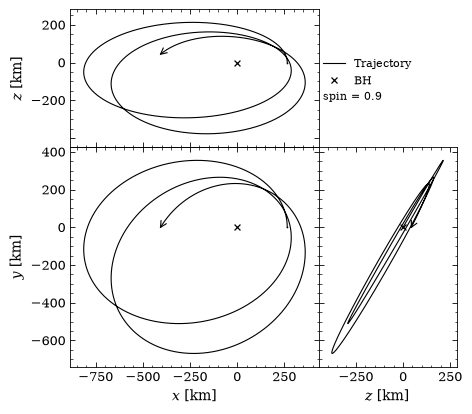

In [3]:
period = orbit.get_keplerian_period()
print("P =", period)

solution = orbit.solve(tau_eval=np.linspace(0, 3, 1500) * period)

print(solution.message)
fig, axes = solution.plot()

The integrated Kerr orbit does not close: its periapsis advances from one
turn to the next, while the preview only shows the ellipse that matches the
starting point.

## 2. Prograde against retrograde

Bound orbits can also be set up with Kerr parameters:

- semi-latus rectum `p`;
- eccentricity `e`;
- inclination parameter `x`, where `x = 1` is an equatorial prograde orbit and
  `x = -1` an equatorial retrograde one.

With the
same `p` and `e`, the two orbits precess very differently around a rapidly
spinning black hole.

prograde ISCO:   1.1604415208809433 r_s
retrograde ISCO: 4.3586761398032445 r_s


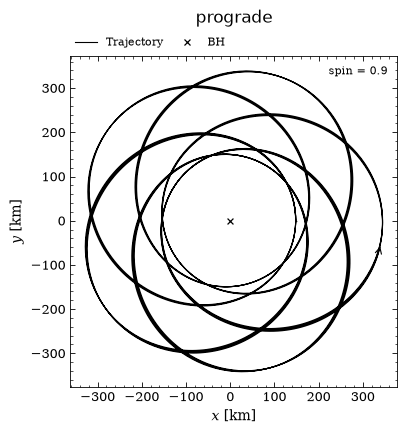

In [4]:
print("prograde ISCO:  ", (bh.r_isco_prograde / bh.r_s).decompose(), "r_s")
print("retrograde ISCO:", (bh.r_isco_retrograde / bh.r_s).decompose(), "r_s")

tau = np.linspace(0, 4000, 3000) * (bh.r_s / c).to(u.s)
prograde = bh.orbit(p=(7 * bh.r_s).to(u.km), e=0.4, x=1.0).solve(tau_eval=tau)
retrograde = bh.orbit(p=(7 * bh.r_s).to(u.km), e=0.4, x=-1.0).solve(tau_eval=tau)

fig, ax = prograde.plot(projection="xy")
ax.set_title("prograde", pad=24);

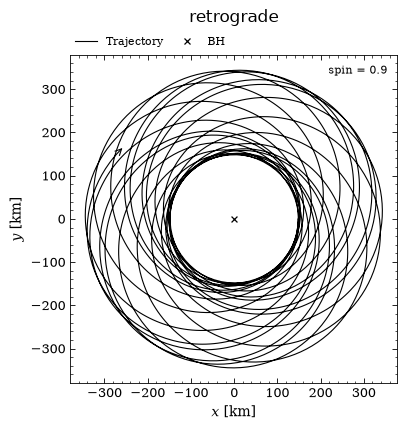

In [5]:
fig, ax = retrograde.plot(projection="xy")
ax.set_title("retrograde", pad=24);

## 3. A star around Sgr A*

Physical units work the same way. Here a star has a semi-major axis of
$1045\,\mathrm{au}$ and an eccentricity of $0.884$, close to the values
reported for the star S2, around a black hole of $4.35 \times 10^6\,M_\odot$.
The orbit lies in the black hole's equatorial plane; it does not reproduce the
orientation of S2 on the sky. We integrate two Keplerian periods, about $32$ years
of proper time.

P = 16.19712782284712 yr


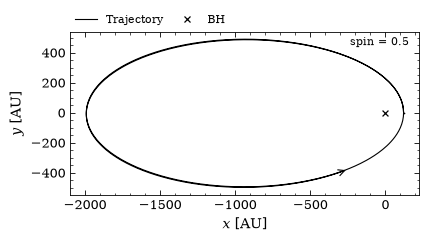

In [6]:
sgr_a = rp.Kerr(mass=4.35e6 * u.Msun, spin=0.5)
star = sgr_a.orbit(a=1045 * u.au, e=0.884)
period = star.get_keplerian_period()
print("P =", period.to(u.yr))
solution = star.solve(tau_eval=np.linspace(0, 2, 2000) * period)

fig, axes = solution.plot(projection="xy")

Far from the black hole the motion is almost Keplerian. `plot_evol` with
`coords="elements"` shows the osculating semi-major axis, eccentricity and true
anomaly along the orbit: they stay nearly constant and change only around the
periapsis passages, where the relativistic corrections are largest.

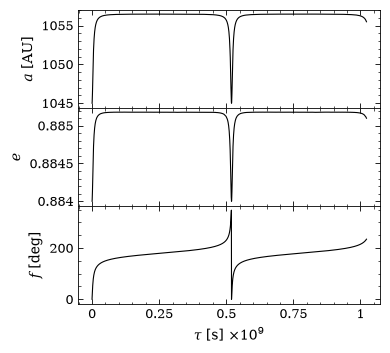

In [7]:
fig, axes = solution.plot_evol(time="tau", coords="elements")

The solution can be queried at any time inside the integrated span; the state
is interpolated, without integrating again.

In [8]:
state = solution.at(tau=10 * u.yr)
print("position:", state.xyz.to(u.au))
print("distance:", state.r.to(u.au))

position: [-1.92302734e+03 -1.77237058e+02  1.18250527e-13] AU
distance: 1931.1776561279244 AU


## Next steps

- [Initial conditions](02-initial-conditions.ipynb): every way to set up an orbit.
- [Integration controls](03-integration-controls.ipynb): methods, tolerances and outcomes.
- [Solutions and states](04-solutions-and-states.ipynb): what a solution stores and how to query it.
- [Plotting](05-plotting.ipynb): previews, projections and publication figures.
- {doc}`../reference/index`: the API reference.